In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
import sys
from scipy import sparse
from scipy.integrate import quad

In [8]:
# Partie 1 : Inversion de matrices de grande dimension
def taille_memoire(mat):
    return mat.nbytes / (1024**2)  

In [9]:

M = 1000
# generer une matrice aléatoire dense
A = np.random.rand(M, M)

print(f"taille de la matrice : {M}x{M}")
print(f"mémoire approximative utilisée : {taille_memoire(A):.2f} Mo")

taille de la matrice : 1000x1000
mémoire approximative utilisée : 7.63 Mo


In [10]:
start_time = time.time()

# inversion de la matrice
A_inv = np.linalg.inv(A)

end_time = time.time()

print(f"temps pour inverser une matrice {M}x{M} : {end_time - start_time:.2f} secondes")

temps pour inverser une matrice 1000x1000 : 0.33 secondes


In [6]:
# verifier que l'inverse est correct : A * A_inv ≈ I
I = np.dot(A, A_inv)
erreur = np.linalg.norm(I - np.eye(M))
print(f"Erreur par rapport à la matrice identité : {erreur:.2e}")

Erreur par rapport à la matrice identité : 3.00e-10


In [7]:
tailles = [100, 500, 1000]  # Tu peux ajouter 2000 si ton PC le permet

for M in tailles:
    A = np.random.rand(M, M)
    print(f"\nMatrice {M}x{M} - Mémoire : {taille_memoire(A):.2f} Mo")
    
    start_time = time.time()
    A_inv = np.linalg.inv(A)
    end_time = time.time()
    
    print(f"Temps d'inversion : {end_time - start_time:.2f} secondes")


Matrice 100x100 - Mémoire : 0.08 Mo
Temps d'inversion : 0.09 secondes

Matrice 500x500 - Mémoire : 1.91 Mo
Temps d'inversion : 0.17 secondes

Matrice 1000x1000 - Mémoire : 7.63 Mo
Temps d'inversion : 0.13 secondes


In [2]:
# Partie 2 : Matrices creuses
n = 1000

# matrice identité creuse
A_sparse = sparse.eye(n, format="csr")

print("Matrice creuse créée")
print("Nombre d'éléments non nuls :", A_sparse.nnz)

Matrice creuse créée
Nombre d'éléments non nuls : 1000


In [3]:
from scipy.sparse.linalg import inv

start_time = time.time()

A_sparse_inv = inv(A_sparse)

end_time = time.time()

print(f"Temps inversion matrice creuse : {end_time - start_time:.4f} secondes")

/home/meryem/anaconda3/envs/cours_ia/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/meryem/anaconda3/envs/cours_ia/lib/python3.11/site-packages/scipy/sparse/linalg/_matfuncs.py:76: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  Ainv = spsolve(A, I)


Temps inversion matrice creuse : 0.6916 secondes


In [5]:
# Partie 3 : Intégration de matrices de fonctions
matrice_fonctions = np.array([
    [lambda t: t, lambda t: t**2],
    [lambda t: 1, lambda t: np.exp(t)]
])

In [6]:
def integrer_matrice(mat, a, b):

    lignes, colonnes = mat.shape

    resultat = np.zeros((lignes, colonnes))

    for i in range(lignes):
        for j in range(colonnes):

            valeur, _ = quad(mat[i, j], a, b)

            resultat[i, j] = valeur

    return resultat

In [7]:
resultat = integrer_matrice(matrice_fonctions, 0, 1)

print("Résultat de l'intégrale de la matrice :")
print(resultat)

Résultat de l'intégrale de la matrice :
[[0.5        0.33333333]
 [1.         1.71828183]]


In [9]:
# partie4 :Leslie
L = np.array([
    [0, 3, 1],
    [0.6, 0, 0],
    [0, 0.5, 0]
])

print("Matrice de Leslie :")
print(L)

Matrice de Leslie :
[[0.  3.  1. ]
 [0.6 0.  0. ]
 [0.  0.5 0. ]]


In [10]:
# Population initiale
X0 = np.array([50, 30, 10])

print("Population initiale :")
print(X0)

Population initiale :
[50 30 10]


In [11]:
generations = 25

pop = []
X = X0

for i in range(generations):
    pop.append(X)
    X = L @ X

pop = np.array(pop)

print("Evolution de la population :")
print(pop)

Evolution de la population :
[[5.00000000e+01 3.00000000e+01 1.00000000e+01]
 [1.00000000e+02 3.00000000e+01 1.50000000e+01]
 [1.05000000e+02 6.00000000e+01 1.50000000e+01]
 [1.95000000e+02 6.30000000e+01 3.00000000e+01]
 [2.19000000e+02 1.17000000e+02 3.15000000e+01]
 [3.82500000e+02 1.31400000e+02 5.85000000e+01]
 [4.52700000e+02 2.29500000e+02 6.57000000e+01]
 [7.54200000e+02 2.71620000e+02 1.14750000e+02]
 [9.29610000e+02 4.52520000e+02 1.35810000e+02]
 [1.49337000e+03 5.57766000e+02 2.26260000e+02]
 [1.89955800e+03 8.96022000e+02 2.78883000e+02]
 [2.96694900e+03 1.13973480e+03 4.48011000e+02]
 [3.86721540e+03 1.78016940e+03 5.69867400e+02]
 [5.91037560e+03 2.32032924e+03 8.90084700e+02]
 [7.85107242e+03 3.54622536e+03 1.16016462e+03]
 [1.17988407e+04 4.71064345e+03 1.77311268e+03]
 [1.59050430e+04 7.07930442e+03 2.35532173e+03]
 [2.35932350e+04 9.54302582e+03 3.53965221e+03]
 [3.21687297e+04 1.41559410e+04 4.77151291e+03]
 [4.72393359e+04 1.93012378e+04 7.07797050e+03]
 [6.4981683

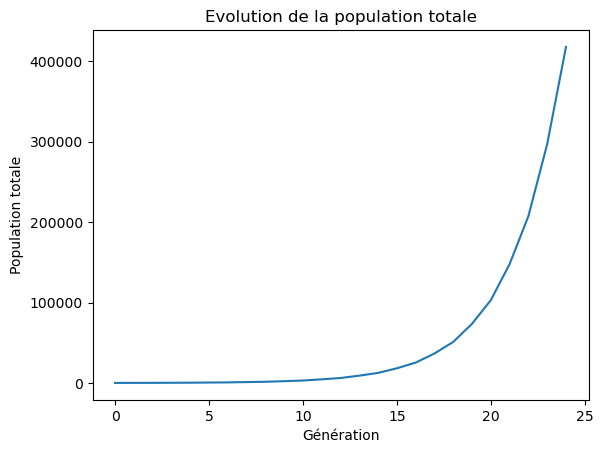

In [12]:
total_population = pop.sum(axis=1)

plt.plot(total_population)

plt.xlabel("Génération")
plt.ylabel("Population totale")
plt.title("Evolution de la population totale")

plt.show()

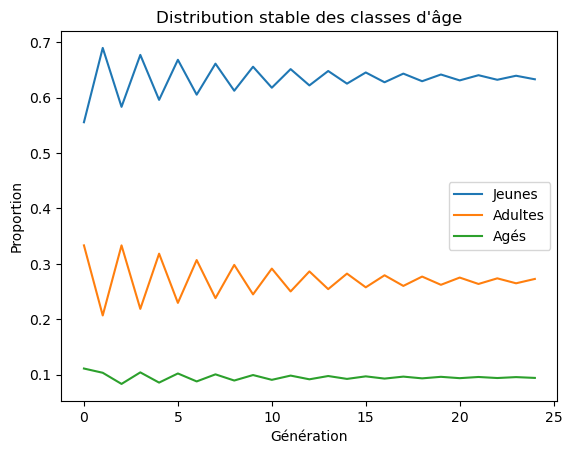

In [13]:
proportion = pop / pop.sum(axis=1, keepdims=True)

plt.plot(proportion[:,0], label="Jeunes")
plt.plot(proportion[:,1], label="Adultes")
plt.plot(proportion[:,2], label="Agés")

plt.xlabel("Génération")
plt.ylabel("Proportion")
plt.title("Distribution stable des classes d'âge")

plt.legend()
plt.show()

In [15]:
values, vectors = np.linalg.eig(L)

print("Valeurs propres :")
print(values)

Valeurs propres :
[ 1.4182819  -1.24891622 -0.16936567]


In [16]:
lambda_max = max(values)

print("Valeur propre dominante :", lambda_max)

Valeur propre dominante : 1.4182818954270653


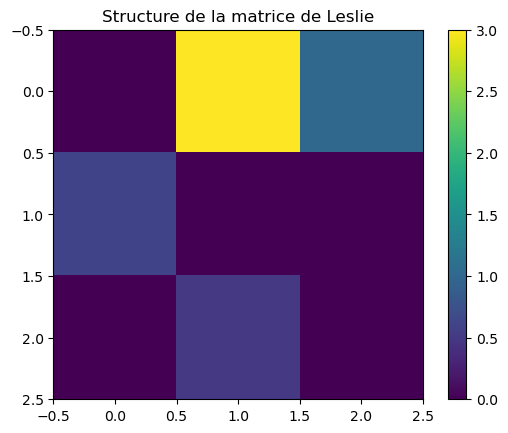

In [17]:
plt.imshow(L)
plt.colorbar()

plt.title("Structure de la matrice de Leslie")

plt.show()